# PR-4/5: Linear Probe Qualitative Evaluation

Evaluates trained linear probes to understand how well each transformer layer's residual stream encodes interpretable time series properties.

## Features probed

| Feature | Type | Baseline |
|---------|------|----------|
| `slope` | Regression (R²) | 0.0 |
| `log_noise_var` | Regression (R²) | 0.0 |
| `phase_cos` | Regression (R²) | 0.0 |
| `phase_sin` | Regression (R²) | 0.0 |
| `period_idx` | Classification (accuracy) | 0.125 (8-class chance) |

Features and baselines are **auto-discovered** from `results/metadata.json` — adding new features requires no changes here.

## Running this notebook

**Option A** — Use pre-computed results from `train_probes.py`:
```bash
python -m experiments.mech_interp.block1_probing.train_probes \
    --moiraie-ckpt /path/to/moiraie \
    --moiraic-ckpt /path/to/moiraic
```

**Option B** — Run end-to-end in this notebook with tiny in-memory models (demo mode, random weights).

Figures are saved to `figures/probe_{feature}.pdf` regardless of mode.

In [1]:
import glob
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

# Repo root on sys.path
REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from experiments.mech_interp.lib import generate_dataset
from experiments.mech_interp.block1_probing.train_probes import (
    extract_activations, run_probes_for_model,
    REGRESSION_FEATURES, CLASSIFICATION_FEATURES,
    PATCH_SIZE, CONTEXT_PATCHES, PRED_PATCHES,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
RESULTS_DIR = os.path.join(NOTEBOOK_DIR, 'results')
FIGURES_DIR = os.path.join(NOTEBOOK_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Results dir : {RESULTS_DIR}")
print(f"Figures dir : {FIGURES_DIR}")

Results dir : /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/results
Figures dir : /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures


## Auto-discover models and load metadata

In [12]:
# ── Model discovery: any *.json in results/ except metadata.json ───────────────
model_jsons = sorted(glob.glob(os.path.join(RESULTS_DIR, '*.json')))
model_jsons = [p for p in model_jsons if os.path.basename(p) != 'metadata.json']
model_names = [os.path.splitext(os.path.basename(p))[0] for p in model_jsons]

print("Model JSONs found:", model_names or "none")

# ── Feature metadata: baselines + metric labels ────────────────────────────────
meta_path = os.path.join(RESULTS_DIR, 'metadata.json')
if os.path.exists(meta_path):
    with open(meta_path) as f:
        feature_meta = json.load(f)['features']
    print(f"Loaded metadata.json ({len(feature_meta)} features)")
else:
    # Fallback: build from train_probes constants
    feature_meta = {
        **{f: {'type': 'regression', 'baseline': 0.0, 'metric': 'R²'} for f in REGRESSION_FEATURES},
        **{f: {'type': 'classification', 'baseline': 1.0 / 8, 'metric': 'accuracy', 'n_classes': 8}
           for f in CLASSIFICATION_FEATURES},
    }
    print("No metadata.json found — using defaults from train_probes constants.")

print("Feature metadata:", {k: v['metric'] for k, v in feature_meta.items()})

Model JSONs found: none
No metadata.json found — using defaults from train_probes constants.
Feature metadata: {'slope': 'R²', 'log_noise_var': 'R²', 'phase_cos': 'R²', 'phase_sin': 'R²', 'period_idx': 'accuracy'}


## Load or generate probe results

In [13]:
def load_results(path):
    """Load probe results JSON, converting string layer keys to ints."""
    with open(path) as f:
        raw = json.load(f)
    return {feat: {int(k): v for k, v in layers.items()} for feat, layers in raw.items()}


USE_REAL_RESULTS = len(model_jsons) > 0

if USE_REAL_RESULTS:
    print("Loading pre-computed probe results.")
    results = {name: load_results(path) for name, path in zip(model_names, model_jsons)}
else:
    print("No pre-computed results found. Running with real checkpoints (DEMO MODE).")
    import torch
    from uni2ts.model.moiraie.module import MoiraieModule
    from uni2ts.model.moiraic.module import MoiraicModule

    device = 'cuda:7' if torch.cuda.is_available() else 'cpu'
    module_e = MoiraieModule.from_pretrained(
        "/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_7/HF_checkpoints/last"
    ).eval().to(device)
    module_c = MoiraicModule.from_pretrained(
        "/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gift_eval_pretrain_weighted/moiraic_training_11/HF_checkpoints/last"
    ).eval().to(device)

    dataset = generate_dataset(n=500, seed=42)
    rng = np.random.default_rng(42)
    idx = rng.permutation(500)
    train_idx, val_idx = idx[:400], idx[400:]

    print("Fitting probes on moiraie...")
    results = {
        'moiraie': run_probes_for_model(module_e, dataset, train_idx, val_idx, batch_size=32, device=device),
        'moiraic': run_probes_for_model(module_c, dataset, train_idx, val_idx, batch_size=32, device=device),
    }
    model_names = list(results.keys())
    print("Done.")

# ── Feature + layer discovery ──────────────────────────────────────────────────
# Union of all features across all models, in consistent insertion order
all_features = list(dict.fromkeys(f for r in results.values() for f in r))
num_layers = max(len(v) for r in results.values() for v in r.values())
layers = list(range(num_layers))

print(f"\nModels   : {model_names}")
print(f"Features : {all_features}")
print(f"Layers   : {num_layers}")

No pre-computed results found. Running with real checkpoints (DEMO MODE).
Loading weights from local directory
Loading weights from local directory
Fitting probes on moiraie...
  Extracting train activations (400 examples)...
  Extracting val activations (100 examples)...


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.29704e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.08114e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.21968e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.64017e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a

    slope: best layer score = 0.9368


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.29704e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.08114e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.21968e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.64017e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a

    log_noise_var: best layer score = 0.7911


...

    log_noise_var: best layer score = 0.8137


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.41996e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.36535e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.68722e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.71199e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a

    phase_cos: best layer score = 0.4829


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.41996e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.36535e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.68722e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.71199e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a

    phase_sin: best layer score = 0.6006
    period_idx: best layer score = 0.9500
Done.

Models   : ['moiraie', 'moiraic']
Features : ['slope', 'log_noise_var', 'phase_cos', 'phase_sin', 'period_idx']
Layers   : 8


## Layer-by-layer probe scores

One figure per feature — saved to `figures/probe_{feature}.pdf`.

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/probe_slope.pdf


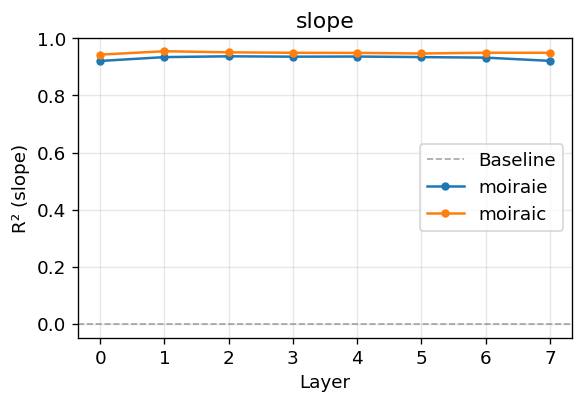

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/probe_log_noise_var.pdf


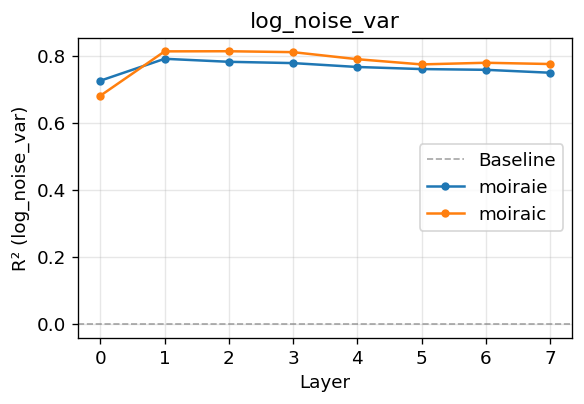

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/probe_phase_cos.pdf


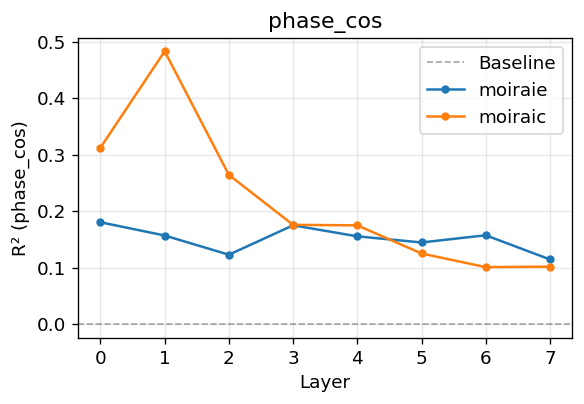

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/probe_phase_sin.pdf


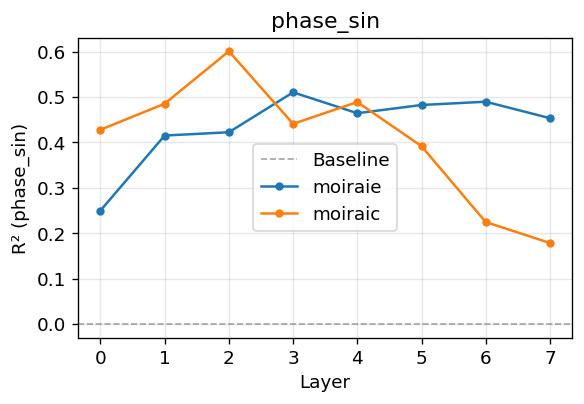

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/probe_period_idx.pdf


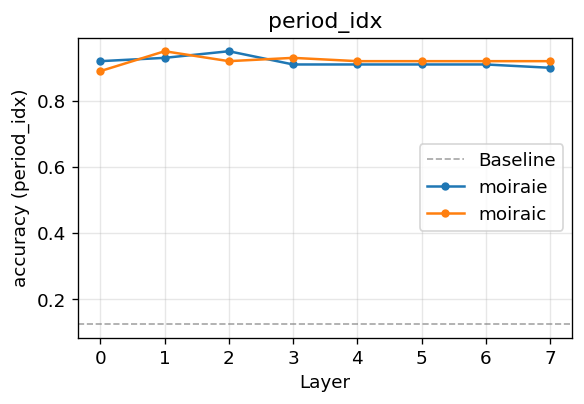

In [14]:
# Assign colors from matplotlib prop_cycle — deterministic, scales to any number of models
prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
model_colors = {name: prop_cycle[i % len(prop_cycle)] for i, name in enumerate(model_names)}

for feature in all_features:
    meta = feature_meta.get(feature, {'type': 'regression', 'baseline': 0.0, 'metric': 'R²'})
    baseline = meta['baseline']
    metric_label = meta['metric']

    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Baseline')

    for model_name in model_names:
        model_results = results[model_name]
        if feature not in model_results:
            continue
        scores = [model_results[feature].get(l, float('nan')) for l in layers]
        ax.plot(layers, scores, marker='o', markersize=4,
                color=model_colors[model_name], label=model_name)

    ax.set_xlabel('Layer')
    ax.set_ylabel(f"{metric_label} ({feature})")
    ax.set_title(feature)
    ax.set_xticks(layers)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(FIGURES_DIR, f'probe_{feature}.pdf')
    fig.savefig(save_path, bbox_inches='tight')
    print(f"Saved {save_path}")
    plt.show()
    plt.close(fig)

## Per-patch × layer probing (PR-5a)

Probes at each **(layer, patch_position)** pair — no mean-pooling across the context. This answers:
- **How much context** does each model need to detect a feature?
- **Encoder (moiraie)**: bidirectional attention means even patch 0 at layer 0 has access to all context.
- **Decoder (moiraic)**: causal attention means patch p only sees patches 0..p; features should emerge later.

Results come from `results/*_per_patch.json`. Section is skipped automatically if those files don't exist yet.

Run with: `python -m experiments.mech_interp.block1_probing.train_probes --per-patch`

In [15]:
from experiments.mech_interp.block1_probing.plot_probes_patch import (
    load_per_patch_results, load_metadata as load_patch_metadata, _scores_to_grid,
)

# Auto-discover per-patch result files
per_patch_jsons = sorted(glob.glob(os.path.join(RESULTS_DIR, '*_per_patch.json')))
per_patch_model_names = [os.path.basename(p).replace('_per_patch.json', '') for p in per_patch_jsons]

if per_patch_jsons:
    per_patch_results = {name: load_per_patch_results(path)
                         for name, path in zip(per_patch_model_names, per_patch_jsons)}
    patch_feature_meta = load_patch_metadata(RESULTS_DIR)
    patch_all_features = list(dict.fromkeys(f for r in per_patch_results.values() for f in r))
    print(f'Per-patch models   : {per_patch_model_names}')
    print(f'Per-patch features : {patch_all_features}')
else:
    per_patch_results = {}
    print('No *_per_patch.json files found. Run train_probes.py --per-patch to generate them.')

No *_per_patch.json files found. Run train_probes.py --per-patch to generate them.


In [16]:
if per_patch_results:
    patch_prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    patch_model_colors = {name: patch_prop_cycle[i % len(patch_prop_cycle)]
                          for i, name in enumerate(per_patch_model_names)}

    for feature in patch_all_features:
        meta = patch_feature_meta.get(feature, {'type': 'regression', 'baseline': 0.0, 'metric': 'R²'})
        baseline = meta['baseline']
        metric_label = meta['metric']

        all_grids = {
            name: _scores_to_grid(per_patch_results[name][feature])
            for name in per_patch_model_names
            if feature in per_patch_results[name]
        }
        if not all_grids:
            continue

        vmin = baseline
        vmax = max(np.nanmax(g) for g in all_grids.values())
        vmax = max(vmax, baseline + 0.01)

        # Heatmap: patch index (x) × layer (y)
        n_models = len(all_grids)
        fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models + 1, 4), squeeze=False)
        im = None
        for ax, model_name in zip(axes[0], per_patch_model_names):
            if model_name not in all_grids:
                ax.set_visible(False)
                continue
            grid = all_grids[model_name]   # [num_layers, num_patches]
            num_patches = grid.shape[1]
            im = ax.imshow(grid, aspect='auto', origin='lower', cmap='viridis',
                           vmin=vmin, vmax=vmax, interpolation='nearest')
            ax.set_xlabel('Patch index')
            ax.set_ylabel('Layer')
            ax.set_title(model_name)
            ax.set_xticks(range(0, num_patches, max(1, num_patches // 8)))
            ax.set_yticks(range(grid.shape[0]))
        if im is not None:
            cb = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            cb.set_label(f'{metric_label}  (baseline={baseline:.3f})')
        fig.suptitle(f'{feature} — probe score by patch × layer', fontsize=12, fontweight='bold')
        plt.tight_layout()
        save_path = os.path.join(FIGURES_DIR, f'probe_patch_{feature}.pdf')
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved {save_path}')
        plt.show()
        plt.close(fig)

        # Slice: last layer, score vs. patch_idx (context accumulation plot)
        fig, ax = plt.subplots(figsize=(5, 3.5))
        ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Baseline')
        for model_name in per_patch_model_names:
            if model_name not in all_grids:
                continue
            grid = all_grids[model_name]
            ax.plot(range(grid.shape[1]), grid[-1, :], marker='o', markersize=3,
                    color=patch_model_colors[model_name], label=model_name)
        ax.set_xlabel('Patch index (context position)')
        ax.set_ylabel(f'{metric_label} ({feature})')
        ax.set_title(f'{feature} — last layer, score vs. context position')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        slice_path = os.path.join(FIGURES_DIR, f'probe_patch_slice_{feature}.pdf')
        fig.savefig(slice_path, bbox_inches='tight')
        print(f'Saved {slice_path}')
        plt.show()
        plt.close(fig)

## All-features overview

Single figure with all features side-by-side — useful for a quick visual scan.

In [17]:
fig, axes = plt.subplots(1, len(all_features), figsize=(4 * len(all_features), 4), sharey=False)
if len(all_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, all_features):
    meta = feature_meta.get(feature, {'type': 'regression', 'baseline': 0.0, 'metric': 'R²'})
    ax.axhline(meta['baseline'], color='gray', linestyle='--', linewidth=1, alpha=0.7)
    for model_name in model_names:
        model_results = results[model_name]
        if feature not in model_results:
            continue
        scores = [model_results[feature].get(l, float('nan')) for l in layers]
        ax.plot(layers, scores, marker='o', markersize=4,
                color=model_colors[model_name], label=model_name)
    ax.set_xlabel('Layer')
    ax.set_ylabel(meta['metric'])
    ax.set_title(feature)
    ax.set_xticks(layers)
    ax.grid(True, alpha=0.3)

legend_elements = [
    Line2D([0], [0], color=model_colors[n], marker='o', markersize=4, label=n)
    for n in model_names
] + [Line2D([0], [0], color='gray', linestyle='--', label='Baseline')]
fig.legend(handles=legend_elements, loc='upper center', ncol=len(model_names) + 1,
           bbox_to_anchor=(0.5, 1.05))
fig.suptitle('Linear Probe Scores by Layer', y=1.08, fontsize=13, fontweight='bold')
plt.tight_layout()

overview_path = os.path.join(FIGURES_DIR, 'probe_overview.pdf')
fig.savefig(overview_path, bbox_inches='tight')
print(f"Saved {overview_path}")
plt.show()
plt.close(fig)

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/probe_overview.pdf


## Summary table: best layer and peak score per feature × model

In [18]:
rows = []
for feature in all_features:
    meta = feature_meta.get(feature, {'type': 'regression', 'baseline': 0.0, 'metric': 'R²'})
    for model_name in model_names:
        model_results = results[model_name]
        if feature not in model_results:
            continue
        layer_scores = model_results[feature]
        best_layer = max(layer_scores, key=layer_scores.get)
        peak_score = layer_scores[best_layer]
        rows.append({
            'Feature': feature,
            'Model': model_name,
            'Metric': meta['metric'],
            'Best Layer': best_layer,
            'Peak Score': round(peak_score, 4),
            'Baseline': round(meta['baseline'], 4),
            'Above baseline': peak_score > meta['baseline'],
        })

df = pd.DataFrame(rows)
summary_path = os.path.join(FIGURES_DIR, 'probe_summary.csv')
df.to_csv(summary_path, index=False)
print(f"Summary saved to {summary_path}")
df

Summary saved to /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/probe_summary.csv


,Feature,Model,Metric,Best Layer,Peak Score,Baseline,Above baseline
0,slope,moiraie,R²,2,0.9368,0.000,True
1,slope,moiraic,R²,1,0.9545,0.000,True
2,log_noise_var,moiraie,R²,1,0.7911,0.000,True
3,log_noise_var,moiraic,R²,2,0.8137,0.000,True
4,phase_cos,moiraie,R²,0,0.1802,0.000,True
5,phase_cos,moiraic,R²,1,0.4829,0.000,True
6,phase_sin,moiraie,R²,3,0.5101,0.000,True
7,phase_sin,moiraic,R²,2,0.6006,0.000,True
8,period_idx,moiraie,accuracy,2,0.9500,0.125,True
9,period_idx,moiraic,accuracy,1,0.9500,0.125,True


## PCA visualization of mean-pooled activations

Shows how the representation space evolves across layers. Each point is one example; color = ground-truth feature value.

> This section requires torch + a loaded model. It uses a tiny in-memory model by default.

In [19]:
try:
    import torch
    from uni2ts.model.moiraie.module import MoiraieModule
    _HAVE_MODELS = True
except ImportError:
    _HAVE_MODELS = False
    print("Cannot import models — skipping PCA section.")

In [20]:
if _HAVE_MODELS:
    _TINY_PCA = dict(d_model=64, d_ff=128, num_layers=num_layers, patch_size=PATCH_SIZE,
                     max_seq_len=64, attn_dropout_p=0., dropout_p=0.)
    pca_module = MoiraieModule(**_TINY_PCA, num_predict_token=1).eval()

    pca_dataset = generate_dataset(n=200, seed=7)
    print(f"PCA dataset: {pca_dataset['series'].shape}")

    print("Extracting activations for PCA...")
    pca_acts = extract_activations(pca_module, pca_dataset['series'], batch_size=32)
    print("Done.")

PCA dataset: (200, 576)
Extracting activations for PCA...
Done.


In [21]:
if _HAVE_MODELS:
    from matplotlib.cm import get_cmap

    # Use discovered features that exist in the PCA dataset
    pca_features = [f for f in all_features if f in pca_dataset]
    pca_layers_to_show = list(range(min(num_layers, 4)))

    for color_feature in pca_features:
        labels = pca_dataset[color_feature]
        is_categorical = feature_meta.get(color_feature, {}).get('type') == 'classification'

        fig, axes = plt.subplots(1, len(pca_layers_to_show),
                                 figsize=(4.5 * len(pca_layers_to_show), 4))
        if len(pca_layers_to_show) == 1:
            axes = [axes]

        for ax, layer_idx in zip(axes, pca_layers_to_show):
            X = pca_acts[layer_idx]
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)

            if is_categorical:
                cmap = get_cmap('tab10')
                unique_labels = np.unique(labels)
                for lbl in unique_labels:
                    mask = labels == lbl
                    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                               c=[cmap(int(lbl) / max(len(unique_labels) - 1, 1))],
                               label=f'class {lbl}', s=20, alpha=0.7)
            else:
                sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels,
                                cmap='RdBu_r', s=20, alpha=0.7)
                plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

            var_explained = pca.explained_variance_ratio_.sum()
            ax.set_title(f'Layer {layer_idx}\n(var={var_explained:.1%})')
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')

        fig.suptitle(f'PCA of mean-pooled activations — colored by `{color_feature}`',
                     fontsize=12, fontweight='bold')
        if is_categorical:
            axes[0].legend(fontsize=7, ncol=2, loc='best')
        plt.tight_layout()
        pca_path = os.path.join(FIGURES_DIR, f'pca_{color_feature}.pdf')
        fig.savefig(pca_path, bbox_inches='tight')
        print(f"Saved {pca_path}")
        plt.show()
        plt.close(fig)

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pca_slope.pdf
Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pca_log_noise_var.pdf
Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pca_phase_cos.pdf
Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pca_phase_sin.pdf


/tmp/ipykernel_3179699/2547463153.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')
/tmp/ipykernel_3179699/2547463153.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')
/tmp/ipykernel_3179699/2547463153.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')
/tmp/ipykernel_3179699/2547463153.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and 

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pca_period_idx.pdf


## Interpretation notes

When using real checkpoints, look for:

- **Early emergence**: features appearing in layers 0–2 are likely encoded by the patch embedding or first few attention heads
- **Encoder vs decoder gap**: the encoder (moiraie) having higher R² at earlier layers would support the hypothesis that bidirectional attention forces earlier feature learning
- **Phase components**: `phase_cos` and `phase_sin` probe the same underlying circular label — if one is probed well but not the other, check the FFT-based label generator
- **Period classification**: `period_idx` accuracy well above the 0.125 chance level indicates the residual stream encodes dominant frequency
- **Non-synthetic data**: if `wrap_existing_dataset` + `DEFAULT_GENERATORS` was used, the same feature keys and baselines apply — no changes needed here

## Per-patch × layer probing (PR-5a)

Each point in the heatmap is an independent linear probe trained on activations at a single **(layer, patch_position)** pair.

- **Encoder (moiraie)**: bidirectional attention — patch 0 already attends over the full context, so global features (slope, period) can emerge at any position.
- **Decoder (moiraic)**: causal attention — at patch *p* only patches 0..p are visible, so detection should improve monotonically with patch position.

Heatmap x-axis = patch index in context window (0–31), y-axis = layer. Slice plot = last-layer score vs patch index.


In [3]:
import glob, json, os
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = "/srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/results"
FIGURES_DIR = "/srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures"

# print(os.path.join(RESULTS_DIR, "*_per_patch.json"))
# print("/srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/results/moiraie_per_patch.json")
# print(glob.glob(os.path.join(RESULTS_DIR, "*_per_patch.json")))
# print(glob.glob(RESULTS_DIR))
per_patch_jsons = sorted(glob.glob(os.path.join(RESULTS_DIR, "*_per_patch.json")))

if not per_patch_jsons:
    print("No *_per_patch.json files found — run train_probes.py --per-patch first.")
else:
    def _load_per_patch(path):
        with open(path) as f:
            raw = json.load(f)
        return {
            feat: {int(l): {int(p): v for p, v in pd.items()} for l, pd in ld.items()}
            for feat, ld in raw.items()
        }

    def _to_grid(layer_dict):
        layers = sorted(layer_dict)
        patches = sorted(layer_dict[layers[0]])
        return np.array([[layer_dict[l].get(p, float("nan")) for p in patches] for l in layers])

    # Load metadata for baselines
    meta_path = os.path.join(RESULTS_DIR, "metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            feature_meta = json.load(f)["features"]
    else:
        feature_meta = {}

    pp_model_names = [os.path.basename(p).replace("_per_patch.json", "") for p in per_patch_jsons]
    pp_results = {name: _load_per_patch(path) for name, path in zip(pp_model_names, per_patch_jsons)}
    pp_features = list(dict.fromkeys(f for r in pp_results.values() for f in r))
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    pp_colors = {name: prop_cycle[i % len(prop_cycle)] for i, name in enumerate(pp_model_names)}

    print(f"Models : {pp_model_names}")
    print(f"Features: {pp_features}")


Models : ['moiraic', 'moiraie']
Features: ['slope', 'log_noise_var', 'phase_cos', 'phase_sin', 'period_idx']


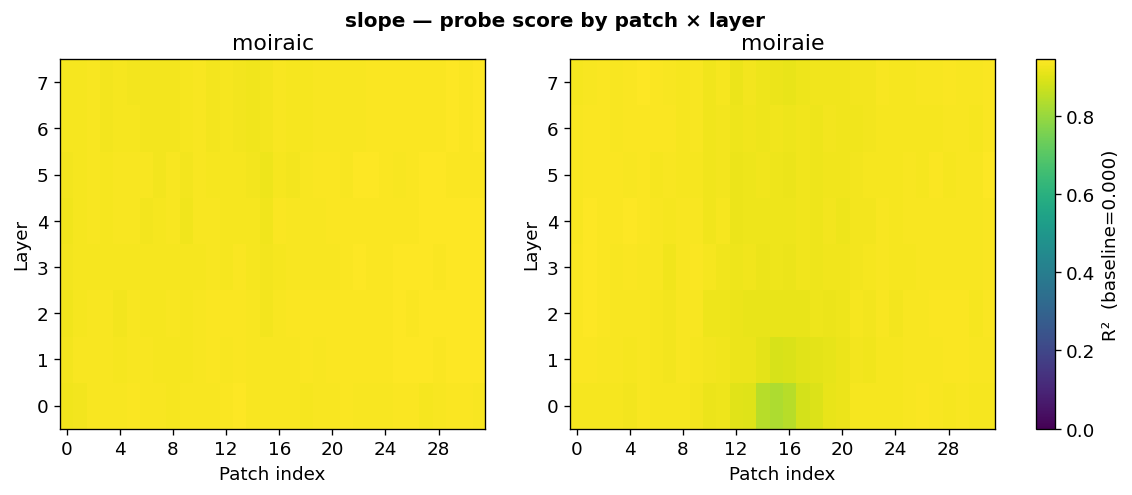

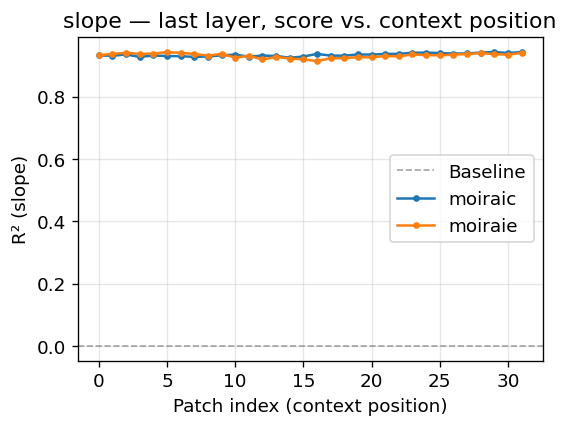

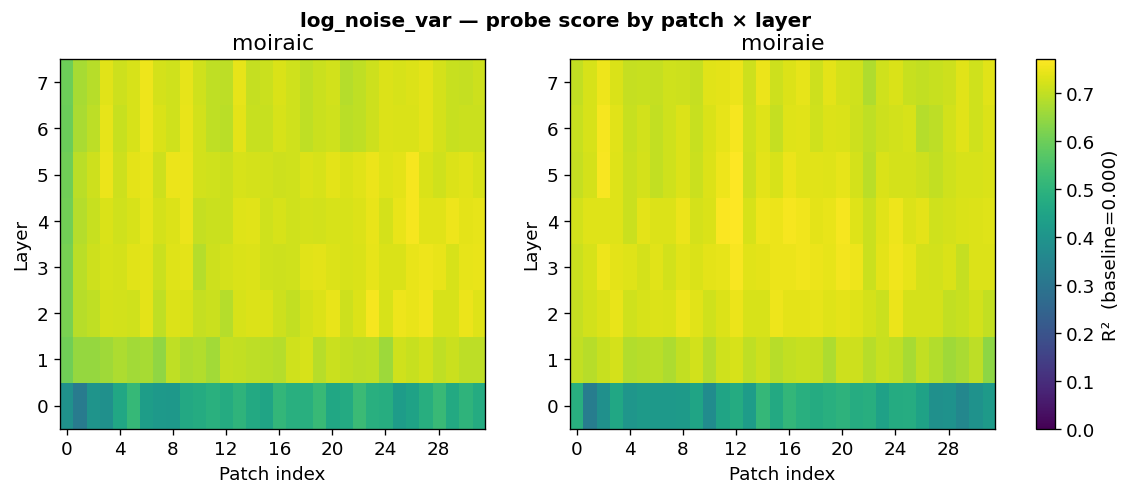

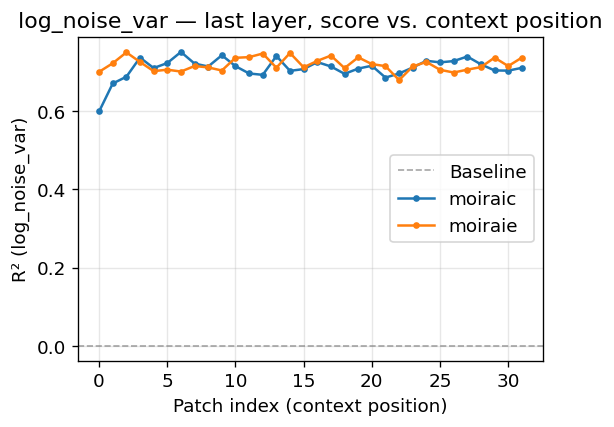

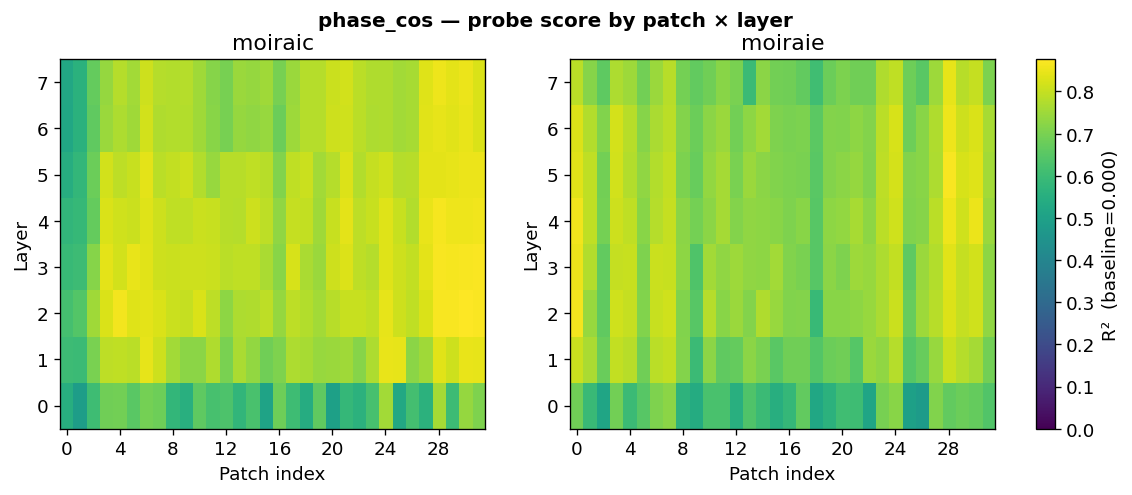

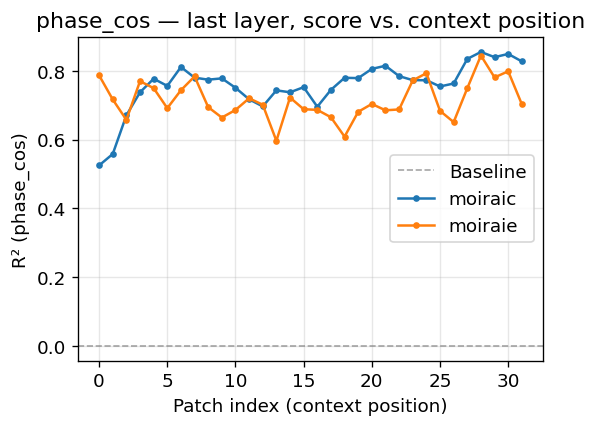

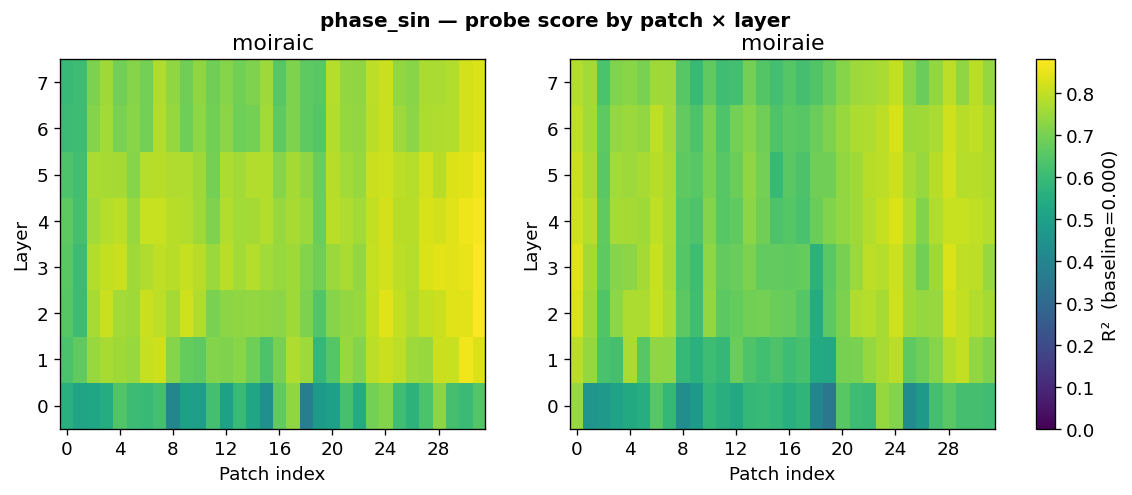

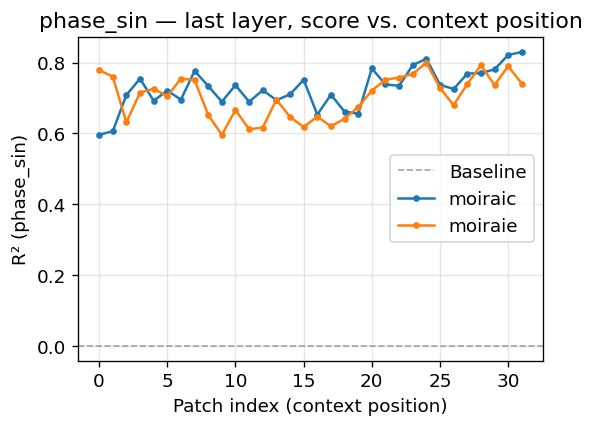

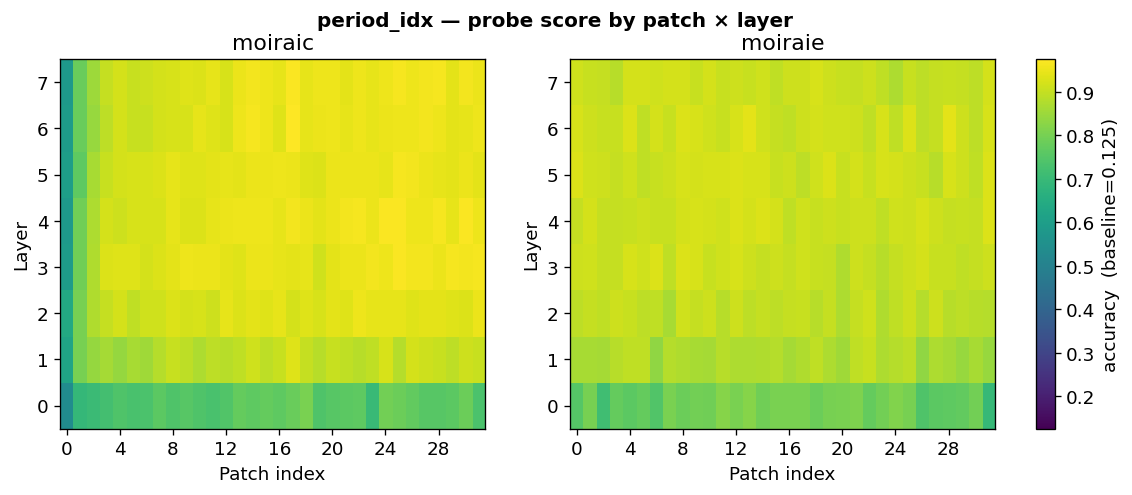

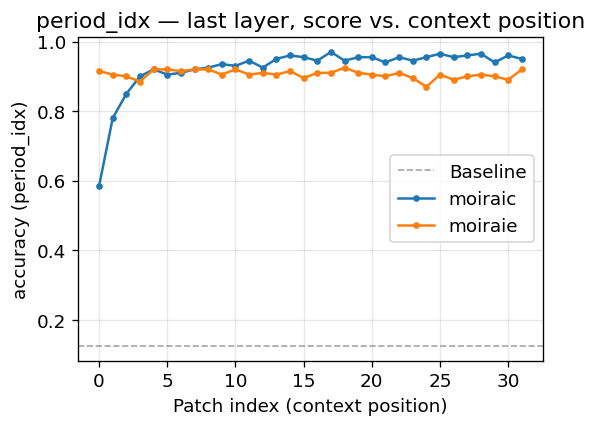

In [4]:
if per_patch_jsons:
    os.makedirs(FIGURES_DIR, exist_ok=True)

    for feature in pp_features:
        meta = feature_meta.get(feature, {"baseline": 0.0, "metric": "R²"})
        baseline = meta["baseline"]
        metric_label = meta["metric"]

        all_grids = {
            name: _to_grid(pp_results[name][feature])
            for name in pp_model_names
            if feature in pp_results[name]
        }
        if not all_grids:
            continue

        vmin = baseline
        vmax = max(np.nanmax(g) for g in all_grids.values())
        vmax = max(vmax, baseline + 0.01)

        # --- Heatmap ---
        n_models = len(all_grids)
        fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models + 1, 4), squeeze=False)
        im = None
        for ax, name in zip(axes[0], pp_model_names):
            if name not in all_grids:
                ax.set_visible(False)
                continue
            grid = all_grids[name]
            im = ax.imshow(grid, aspect="auto", origin="lower", cmap="viridis",
                           vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_xlabel("Patch index")
            ax.set_ylabel("Layer")
            ax.set_title(name)
            ax.set_xticks(range(0, grid.shape[1], max(1, grid.shape[1] // 8)))
            ax.set_yticks(range(grid.shape[0]))
        if im is not None:
            cb = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            cb.set_label(f"{metric_label}  (baseline={baseline:.3f})")
        fig.suptitle(f"{feature} — probe score by patch × layer", fontsize=12, fontweight="bold")
        # plt.tight_layout()
        fig.savefig(os.path.join(FIGURES_DIR, f"probe_patch_{feature}.pdf"), bbox_inches="tight")
        plt.show()

        # --- Slice at last layer ---
        fig, ax = plt.subplots(figsize=(5, 3.5))
        ax.axhline(baseline, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Baseline")
        for name in pp_model_names:
            if name not in all_grids:
                continue
            grid = all_grids[name]
            ax.plot(range(grid.shape[1]), grid[-1, :], marker="o", markersize=3,
                    color=pp_colors[name], label=name)
        ax.set_xlabel("Patch index (context position)")
        ax.set_ylabel(f"{metric_label} ({feature})")
        ax.set_title(f"{feature} — last layer, score vs. context position")
        ax.legend()
        ax.grid(True, alpha=0.3)
        # plt.tight_layout()
        fig.savefig(os.path.join(FIGURES_DIR, f"probe_patch_slice_{feature}.pdf"), bbox_inches="tight")
        plt.show()
